# NeuralEncoder evaluation

Fit a linear encoder and a PCA-driven nonlinear residual on NSD training stimuli. Compare linear and refined embeddings on aligned repetitions of training and held-out test stimuli.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from neural_encoder import NeuralEncoder
from neural_encoder.utils.nsd import get_resource, get_subject_roi, get_shared_stimuli
from neural_encoder.utils import MeasurementPreprocessor, split_views, evaluate_views, ConsoleLogger


In [12]:
subject = 1
rois = [0, 1]
betas_subfolder = "betas_fsaverage"
n_repetitions = 3
n_components_pca = 768
n_components_mcca = 128
n_components_pca_refinement = 1536  # None reuses the linear PCA.
refinement_steps = 2000
refinement_hidden_dim = 768
refinement_device = "auto"
random_state = 42


## Load and split measurements

All repetitions of each stimulus belong to the same split. The configured NSD directory is read from `NSD_DATASET`.

In [3]:
df = (
    get_resource("stimulus")
    .query("subject == @subject and exists")
    .sort_values("subject_index")
    .reset_index(drop=True)
)
shared_stimuli = get_shared_stimuli()
train = ~df.shared.to_numpy(dtype=bool)
#test = ~train
test = df.nsd_id.isin(shared_stimuli).to_numpy(dtype=bool)
df_train = df.loc[train].copy()
df_test = df.loc[test].copy()
assert set(df_train.nsd_id).isdisjoint(df_test.nsd_id)

data = get_subject_roi(subject=subject, roi=rois, subfolder=betas_subfolder)
data_train = data[df_train.subject_index.to_numpy(dtype=int)]
data_test = data[df_test.subject_index.to_numpy(dtype=int)]
del data

pd.DataFrame({
    "measurements": [len(data_train), len(data_test)],
    "stimuli": [df_train.nsd_id.nunique(), df_test.nsd_id.nunique()],
}, index=["train", "test"])

,measurements,stimuli
train,27000,9000
test,1545,515


## Preprocess and fit

Fit preprocessing on training measurements, then learn $z_{\mathrm{MCCA}} + \alpha g(z_{\mathrm{PCA}})$ with `NeuralEncoder`. The two PCA dimensions can be configured independently; equal dimensions share one PCA. Test measurements are used only for evaluation.


In [5]:
processor = MeasurementPreprocessor()
data_train_processed = processor.fit_transform(data_train)
data_test_processed = processor.transform(data_test)
del data_train, data_test

logger = ConsoleLogger(log_frequency=100)
encoder = NeuralEncoder(
    n_components_pca=n_components_pca,
    n_components_mcca=n_components_mcca,
    refinement_input_stage="pca",
    n_components_pca_refinement=n_components_pca_refinement,
    refiner_kwargs={
        "network_kwargs": {"hidden_dim": refinement_hidden_dim, "depth": 1, "dropout": 0.1},
        "initial_alpha": 0.25,
        "trainable_alpha": True,
        "loss_kwargs": {"temperature": 0.09, "nce_weight": 1.0, "pull_weight": 0.5},
        "optimizer_kwargs": {"lr": 1e-4, "weight_decay": 1e-4},
        "steps": refinement_steps,
        "batch_size": 512,
        "device": refinement_device,
        "logger": logger,
    },
    shuffle_views=True,
    random_state=random_state,
)
encoder.fit(
    data_train_processed,
    sample_ids=df_train.nsd_id.to_numpy(),
    view_ids=df_train.repetition.to_numpy(),
)
logger.finish()


step=100 loss=1.7375 lr=0.0001 grad_norm=1.6593 alpha=0.2561
step=200 loss=1.5096 lr=0.0001 grad_norm=1.9112 alpha=0.27023
step=300 loss=1.3055 lr=0.0001 grad_norm=2.0521 alpha=0.28318
step=400 loss=1.1486 lr=0.0001 grad_norm=2.1043 alpha=0.2949
step=500 loss=1.0268 lr=0.0001 grad_norm=2.2043 alpha=0.30542
step=600 loss=0.92292 lr=0.0001 grad_norm=2.1112 alpha=0.31503
step=700 loss=0.84167 lr=0.0001 grad_norm=2.1431 alpha=0.32398
step=800 loss=0.78095 lr=0.0001 grad_norm=2.1629 alpha=0.33201
step=900 loss=0.72815 lr=0.0001 grad_norm=2.2012 alpha=0.33918
step=1000 loss=0.68705 lr=0.0001 grad_norm=2.1196 alpha=0.34577
step=1100 loss=0.65371 lr=0.0001 grad_norm=2.154 alpha=0.35186
step=1200 loss=0.62618 lr=0.0001 grad_norm=2.1067 alpha=0.35748
step=1300 loss=0.60389 lr=0.0001 grad_norm=2.1354 alpha=0.36254
step=1400 loss=0.58392 lr=0.0001 grad_norm=2.1015 alpha=0.36724
step=1500 loss=0.56795 lr=0.0001 grad_norm=2.1279 alpha=0.37151
step=1600 loss=0.55839 lr=0.0001 grad_norm=2.1085 alpha=0

In [11]:
processor

,scaling,300.0
,quantile_clip,0.0005
,clip_bounds,None
,sample_centering,False
,feature_centering,True
,feature_scaling,False
,normalize,False
,fill_value,0.0
,dtype,<class 'numpy.float32'>
Name,Type,Value
clip_bounds_,"ndarray[float64](2,)","[-0.01, 0.01]"


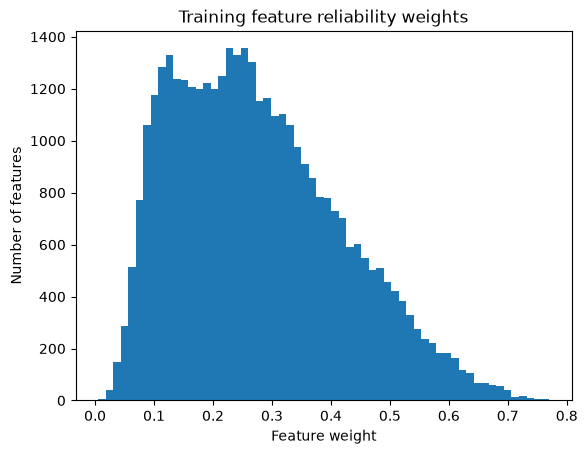

In [6]:
plt.hist(encoder.linear_encoder_.feature_reweighting_.weights_, bins=60)
plt.xlabel("Feature weight")
plt.ylabel("Number of features")
plt.title("Training feature reliability weights")
plt.show()

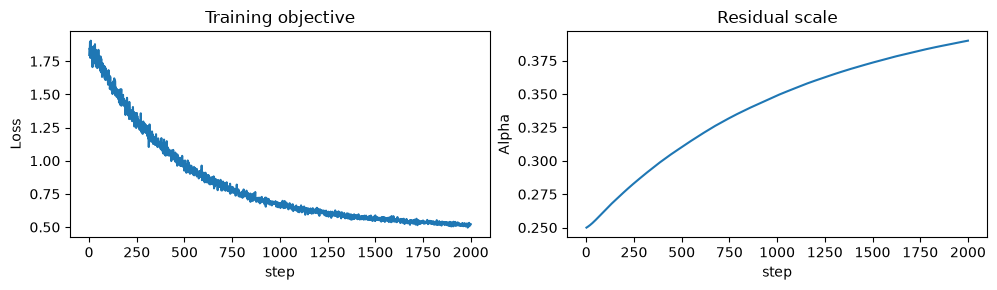

In [7]:
history = pd.DataFrame(encoder.refiner_.history_).set_index("step")
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
history["loss"].plot(ax=axes[0], title="Training objective")
axes[0].set_ylabel("Loss")
history["alpha"].plot(ax=axes[1], title="Residual scale")
axes[1].set_ylabel("Alpha")
fig.tight_layout()
plt.show()

## Align the three repetitions

Discard incomplete stimuli from evaluation instead of filling in measurements. Each returned matrix has the same stimuli in sorted order. Preserve repetition identities here so the pairwise results remain interpretable.

In [8]:
X_train1, X_train2, X_train3 = split_views(
    data_train_processed,
    sample_ids=df_train.nsd_id.to_numpy(),
    view_ids=df_train.repetition.to_numpy(),
    n_views=n_repetitions,
    impute="discard",
)
X_test1, X_test2, X_test3 = split_views(
    data_test_processed,
    sample_ids=df_test.nsd_id.to_numpy(),
    view_ids=df_test.repetition.to_numpy(),
    n_views=n_repetitions,
    impute="discard",
)

pd.DataFrame({
    "complete_stimuli": [len(X_train1), len(X_test1)],
    "features": [X_train1.shape[1], X_test1.shape[1]],
}, index=["train", "test"])

,complete_stimuli,features
train,9000,37984
test,515,37984


## Project and evaluate

Apply the same fitted encoder to every view. Retrieval is evaluated in all six directions; RSA compares Pearson-distance RDMs using Pearson correlation. Lower mean rank is better; higher recall@1, matched cosine, and RSA are better.

In [9]:
train_views = [X_train1, X_train2, X_train3]
test_views = [X_test1, X_test2, X_test3]

Z_train_linear = [encoder.linear_encoder_.transform(X) for X in train_views]
Z_test_linear = [encoder.linear_encoder_.transform(X) for X in test_views]
Z_train_refined = [encoder.transform(X) for X in train_views]
Z_test_refined = [encoder.transform(X) for X in test_views]


In [10]:
metrics = {}
pairs = {}
for stage, splits in {
    "linear": {"train": Z_train_linear, "test": Z_test_linear},
    "neural_encoder": {"train": Z_train_refined, "test": Z_test_refined},
}.items():
    for split, views in splits.items():
        metrics[stage, split], pairs[stage, split] = evaluate_views(views, return_pairs=True)

summary = pd.DataFrame.from_dict(metrics, orient="index")
summary.index.names = ["stage", "split"]
display(summary)
display(pd.concat(pairs, names=["stage", "split", "pair"]))


mean_rank  recall@1    cosine       rsa
stage          split                                         
linear         train  17.221907  0.728574  0.529671  0.401052
               test    2.124272  0.870227  0.525975  0.417995
neural_encoder train   1.080685  0.997833  0.764858  0.659945
               test    1.067314  0.976375  0.699960  0.590100

query_view  candidate_view  mean_rank  recall@1  \
stage          split pair                                                    
linear         train 0              0               1  16.796000  0.733667   
                     1              0               2  19.165333  0.689333   
                     2              1               0  16.227444  0.758444   
                     3              1               2  15.161111  0.745556   
                     4              2               0  19.737000  0.701444   
                     5              2               1  16.244556  0.743000   
               test  0              0               1   2.033010  0.889320   
                     1              0               2   2.611650  0.838835   
                     2              1               0   1.889320  0.895146   
                     3              1               2   1.932039  0.858252   
                     4              2               0   2.382524  0.858252   
                     5              2               1   1.897087  0.881553   
neural_encoder train 0              0               1   1.090111  0.997556   
                     1              0               2   1.051000  0.997778   
                     2              1               0   1.085778  0.998111   
                     3              1               2   1.078444  0.998000   
                     4              2               0   1.066667  0.997333   
                     5              2               1   1.112111  0.998222   
               test  0              0               1   1.073786  0.974757   
                     1              0               2   1.058252  0.970874   
                     2              1               0   1.079612  0.978641   
                     3              1               2   1.079612  0.972816   
                     4              2               0   1.036893  0.980583   
                     5              2               1   1.075728  0.980583   

                             cosine       rsa  
stage          split pair                      
linear         train 0     0.543696  0.412628  
                     1     0.509490  0.387799  
                     2     0.543696  0.412628  
                     3     0.535828  0.402728  
                     4     0.509490  0.387799  
                     5     0.535828  0.402728  
               test  0     0.544476  0.432823  
                     1     0.502937  0.405547  
                     2     0.544476  0.432823  
                     3     0.530512  0.415615  
                     4     0.502937  0.405547  
                     5     0.530512  0.415615  
neural_encoder train 0     0.768418  0.665480  
                     1     0.762763  0.658475  
                     2     0.768418  0.665480  
                     3     0.763392  0.655880  
                     4     0.762763  0.658475  
                     5     0.763392  0.655880  
               test  0     0.703138  0.593136  
                     1     0.699340  0.592471  
                     2     0.703138  0.593136  
                     3     0.697401  0.584694  
                     4     0.699340  0.592471  
                     5     0.697401  0.584694

## PyTorch architecture

Export the complete fitted encoder and verify that its outputs match the estimator.


In [ ]:
import torch

module = encoder.to_pytorch()
parameter = next(module.parameters())
with torch.no_grad():
    torch_embeddings = module(torch.as_tensor(
        X_test1[:10], device=parameter.device, dtype=parameter.dtype,
    )).cpu().numpy()
np.testing.assert_allclose(torch_embeddings, Z_test_refined[0][:10], rtol=1e-4, atol=1e-4)
print("PyTorch and estimator outputs agree.")


## Comparison: MCCA-input residual refinement

Fit $z_{\mathrm{MCCA}} + \alpha g(z_{\mathrm{MCCA}})$, following the paper's architecture. Reuse the fitted linear encoder and the nonlinear training settings above, changing only the residual input from PCA to MCCA. Test stimuli remain excluded from training.


In [ ]:
from neural_encoder.nonlinear import NonlinearRefiner

mcca_logger = ConsoleLogger(log_frequency=100)
mcca_refiner = NonlinearRefiner(**(
    encoder.refiner_.get_params(deep=False) | {"logger": mcca_logger}
))
mcca_refiner.fit(
    encoder.linear_encoder_.transform(data_train_processed),
    sample_ids=df_train.nsd_id.to_numpy(),
    view_ids=df_train.repetition.to_numpy(),
)
mcca_logger.finish()


In [ ]:
mcca_history = pd.DataFrame(mcca_refiner.history_).set_index("step")
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
mcca_history["loss"].plot(ax=axes[0], title="Training objective (MCCA input)")
axes[0].set_ylabel("Loss")
mcca_history["alpha"].plot(ax=axes[1], title="Residual scale (MCCA input)")
axes[1].set_ylabel("Alpha")
fig.tight_layout()
plt.show()


In [ ]:
Z_train_mcca_refined = [mcca_refiner.transform(Z) for Z in Z_train_linear]
Z_test_mcca_refined = [mcca_refiner.transform(Z) for Z in Z_test_linear]

comparison_metrics = dict(metrics)
comparison_pairs = dict(pairs)
for split, views in {"train": Z_train_mcca_refined, "test": Z_test_mcca_refined}.items():
    key = ("refined_mcca_input", split)
    comparison_metrics[key], comparison_pairs[key] = evaluate_views(views, return_pairs=True)

comparison_summary = pd.DataFrame.from_dict(comparison_metrics, orient="index")
comparison_summary.index.names = ["stage", "split"]
display(comparison_summary)
display(pd.concat(comparison_pairs, names=["stage", "split", "pair"]))
